### NPi recontruction using only CH

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from scipy.optimize import curve_fit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [ ]:
# Load data
df = pd.read_csv("../Modified_Pupilometri/NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)

df = df.dropna(subset=["npi", "ch"])


def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy distribution


df["z_ch"] = z_score(df["ch"], 36.16, 6.04)


TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_ch"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values


X_trans = X.copy()


In [ ]:

# Sigmoid functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b



# Stratified CV setup

y_binned = pd.qcut(df["npi"], q=5, labels=False, duplicates="drop")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores, mae_scores, r2_scores = [], [], []
all_true = []
all_pred = []
all_indices = []



# CV LOOP

for fold, (train_idx, test_idx) in enumerate(cv.split(X_trans, y_binned, groups)):

    print(f"\n--- Fold {fold+1} ---")

    X_train = X_trans.iloc[train_idx]
    X_test  = X_trans.iloc[test_idx]

    y_train_raw = y_raw[train_idx]
    y_test_raw  = y_raw[test_idx]

    # Logit transform
    y_train_scaled = np.clip(y_train_raw / 5, 1e-6, 1-1e-6)
    z_train = np.log(y_train_scaled / (1 - y_train_scaled))


    # Train GAM
    gam = LinearGAM(
        s(0, constraints='monotonic_inc', n_splines=10)
    )
    gam.gridsearch(X_train, z_train)


    # FIT SIGMOID
    x_vals = np.linspace(
        X_train.iloc[:,0].min(),
        X_train.iloc[:,0].max(),
        200
    )

    # Create fake data 
    X_fake = pd.DataFrame(x_vals.reshape(-1,1), columns=X_train.columns)

    y_gam = gam.partial_dependence(term=0, X=X_fake)

    # Initial guess
    p0 = [
        y_gam.max() - y_gam.min(),   # amplitude
        1.0,                         # slope
        np.median(x_vals),           # midpoint
        y_gam.min()                  # offset
    ]

    bounds = (
        [0,     0.01, x_vals.min(), -10],
        [10,    10,   x_vals.max(), 10]
    )

    try:
        params_ch, _ = curve_fit(
            sigmoid_shifted,
            x_vals,
            y_gam,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )
        use_fallback = False

    except RuntimeError:
        print("failed")
        use_fallback = True



    # Intercept

    intercept = (
        gam._modelmat(np.zeros((1, X_train.shape[1]))) @ gam.coef_
    ).item()



    # MODEL

    def f_ch(x):
        if use_fallback:
            return np.interp(x, x_vals, y_gam)
        return sigmoid_shifted(x, *params_ch)


    def predict_z(X):
        return intercept + f_ch(X.iloc[:,0].values)


    # CALIBRATION

    z_train_pred = predict_z(X_train)

    z_train_true = np.log(
        np.clip(y_train_raw/5, 1e-6, 1-1e-6) /
        (1 - np.clip(y_train_raw/5, 1e-6, 1-1e-6))
    )

    reg = LinearRegression().fit(
        z_train_pred.reshape(-1,1),
        z_train_true
    )

    a = reg.coef_[0]
    b = reg.intercept_

    print(f"Calibration: a={a:.3f}, b={b:.3f}")



    # TEST

    z_test_pred = predict_z(X_test)

    z_test_corrected = a * z_test_pred + b
    npi_pred = np.round(sigmoid(z_test_corrected) * 5,1)

    all_true.extend(y_test_raw)
    all_pred.extend(npi_pred)
    all_indices.extend(test_idx)



    # EVALUATION
  
    rmse = np.sqrt(mean_squared_error(y_test_raw, npi_pred))
    mae  = mean_absolute_error(y_test_raw, npi_pred)
    r2   = r2_score(y_test_raw, npi_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)


# Results
print("\n=== FINAL CV RESULTS ===")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



--- Fold 1 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.878, b=-0.090
RMSE: 0.6543
MAE:  0.3956
R2:   0.2392

--- Fold 2 ---


 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00


...

Calibration: a=0.912, b=-0.276
RMSE: 0.5642
MAE:  0.3477
R2:   0.3345

--- Fold 4 ---


 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.890, b=-0.162
RMSE: 0.4915
MAE:  0.3384
R2:   0.2923

--- Fold 5 ---


 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Calibration: a=0.908, b=-0.290
RMSE: 0.4719
MAE:  0.3078
R2:   0.3538

=== FINAL CV RESULTS ===
RMSE: 0.5478 ± 0.0642
MAE:  0.3527 ± 0.0302
R2:   0.2826 ± 0.0596


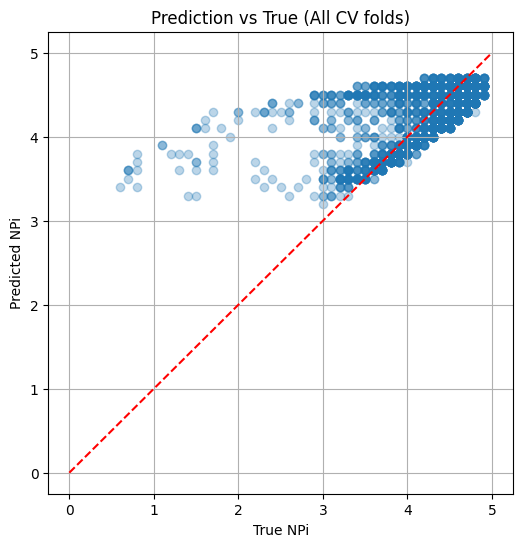

In [ ]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True (All CV folds)")
plt.grid()
plt.show()

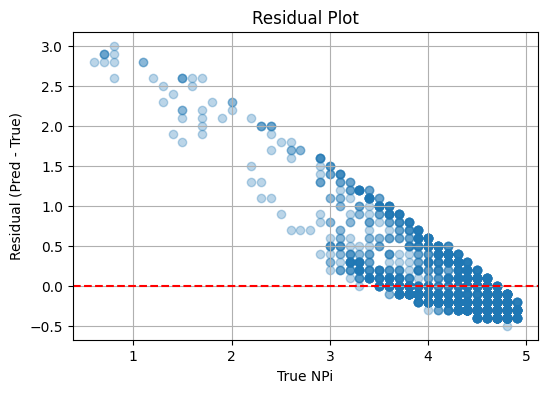

In [5]:
residuals = all_pred - all_true

plt.figure(figsize=(6,4))
plt.scatter(all_true, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()

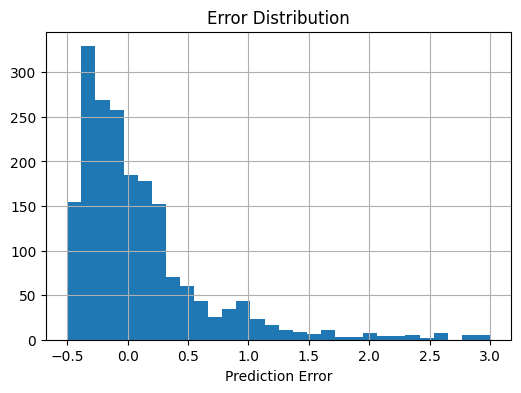

In [7]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()
